# VetXRay Cardiomegaly Detection

This notebook builds a focused binary classifier for one clinical question: **does this X-ray suggest cardiomegaly (an enlarged heart)?**

The workflow is intentionally small:
1. load and preprocess all DICOM images
2. align them with spreadsheet metadata
3. convert the `findings` column into a binary `cardiomegaly` target
4. train a simple linear baseline and a small CNN

Reusable code lives in [vetxray_bigheart_utils.py](/d:/project/vetxray/vetxray_bigheart_utils.py) so the notebook stays readable.


In [8]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm

from vetxray_bigheart_utils import (
    ImageBinaryDataset,
    LinearBaseline,
    XRayCNN,
    binary_f1_fn,
    binary_metric_summary,
    build_cardiomegaly_target,
    build_dicom_tensor,
    eval_binary_epoch,
    load_annotations,
    print_train_time,
    timer,
    train_binary_epoch,
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

DICOM_DIR = Path("RX_1") / "RX_1"
XLSX_PATH = Path("File list with tags.xlsx")
TARGET_SIZE = (224, 224)
LIMIT = None
BATCH_SIZE = 16
THRESHOLD = 0.5

print("DICOM directory:", DICOM_DIR.resolve())
print("Annotations:", XLSX_PATH.resolve())
print("Target size:", TARGET_SIZE)


Using device: cuda
DICOM directory: D:\project\vetxray\RX_1\RX_1
Annotations: D:\project\vetxray\File list with tags.xlsx
Target size: (224, 224)


## Load Images And Metadata

Each DICOM is normalized to `[0, 1]`, resized to a common shape, and stacked into a tensor of shape `[N, 1, H, W]`.


In [2]:
annotations = load_annotations(XLSX_PATH)
image_tensor, metadata_df = build_dicom_tensor(
    DICOM_DIR,
    annotations,
    target_size=TARGET_SIZE,
    limit=LIMIT,
)

print("Tensor shape:", tuple(image_tensor.shape))
metadata_df.head()


Processed 250/2267 DICOM files
Processed 500/2267 DICOM files
Processed 750/2267 DICOM files
Processed 1000/2267 DICOM files
Processed 1250/2267 DICOM files
Processed 1500/2267 DICOM files
Processed 1750/2267 DICOM files
Processed 2000/2267 DICOM files
Processed 2250/2267 DICOM files
Processed 2267/2267 DICOM files
Tensor shape: (2267, 1, 224, 224)


,filename,original_height,original_width,modality,photometric_interpretation,species,breed,projection,quality,findings
0,IM-0004-0001-0001.dcm,2832,2836,CR,MONOCHROME1,Dog,Pinscher,LL,correct,[no_finding]
1,IM-0004-0001-0002.dcm,2134,2791,CR,MONOCHROME1,Dog,Border Collie,LL,correct,"[cardiomegaly, interstitial_pattern, bronchial..."
2,IM-0005-0002.dcm,2605,1917,CR,MONOCHROME1,None,None,None,None,[]
3,IM-0006-0001.dcm,2832,2836,CR,MONOCHROME1,Dog,Greyhound,LL,correct,[mass]
4,IM-0007-0002.dcm,2832,2836,CR,MONOCHROME1,Dog,Greyhound,LL,correct,[mass]


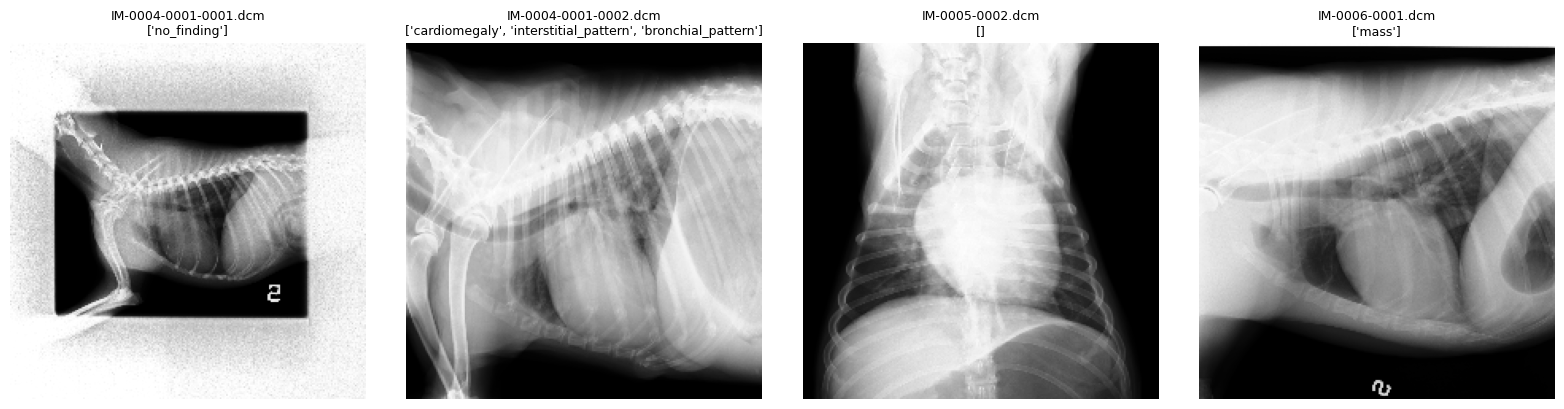

In [3]:
num_preview = min(4, image_tensor.shape[0])
fig, axes = plt.subplots(1, num_preview, figsize=(4 * num_preview, 4))
if num_preview == 1:
    axes = [axes]

for i, ax in enumerate(axes):
    row = metadata_df.iloc[i]
    ax.imshow(image_tensor[i, 0].cpu().numpy(), cmap="gray")
    ax.axis("off")
    ax.set_title(f"{row['filename']}\n{row.get('findings', [])}", fontsize=9)

plt.tight_layout()
plt.show()


## Build The Cardiomegaly Target

The `findings` column contains a list of tags per image. Here we collapse it into a single binary label:
- `1` if `cardiomegaly` appears in the findings list
- `0` otherwise


In [10]:
valid_mask = metadata_df["findings"].notna().to_numpy()
metadata_clean = metadata_df[valid_mask].reset_index(drop=True)
image_tensor_clean = image_tensor[valid_mask]

y = build_cardiomegaly_target(metadata_clean)
print("Positive rate:", float(y.mean()))
print(pd.Series(y).value_counts())


Positive rate: 0.16365240405822673
findings
0.0    1896
1.0     371
Name: count, dtype: int64


In [11]:
indices = list(range(len(metadata_clean)))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    shuffle=True,
    stratify=y,
)

X_train = image_tensor_clean[train_idx]
X_test = image_tensor_clean[test_idx]
y_train = y.iloc[train_idx].reset_index(drop=True)
y_test = y.iloc[test_idx].reset_index(drop=True)

train_data = ImageBinaryDataset(X_train, y_train)
test_data = ImageBinaryDataset(X_test, y_test)

class_counts = y_train.value_counts()
sample_weights = y_train.map({
    0.0: 1.0 / class_counts[0.0],
    1.0: 1.0 / class_counts[1.0],
}).to_numpy()

sampler = WeightedRandomSampler(
    weights=torch.DoubleTensor(sample_weights),
    num_samples=len(sample_weights),
    replacement=True,
)

train_dataloader = DataLoader(train_data, batch_size=BATCH_SIZE, sampler=sampler)
test_dataloader = DataLoader(test_data, batch_size=BATCH_SIZE, shuffle=False)

print("Train size:", len(train_data))
print("Test size:", len(test_data))
print("Train positives:", int(y_train.sum()))
print("Test positives:", int(y_test.sum()))
print("Sampler configured for balanced training batches")


Train size: 1813
Test size: 454
Train positives: 297
Test positives: 74


c:\Users\hsbry\miniconda3\Lib\site-packages\sklearn\utils\validation.py:605: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype):
c:\Users\hsbry\miniconda3\Lib\site-packages\sklearn\utils\validation.py:614: FutureWarning: is_sparse is deprecated and will be removed in a future version. Check `isinstance(dtype, pd.SparseDtype)` instead.
  if is_sparse(pd_dtype) or not is_extension_array_dtype(pd_dtype):


## Baseline 1: Linear Model

This baseline flattens the image and predicts a single cardiomegaly logit. It is a sanity check, not the final model to trust.


In [ ]:
torch.manual_seed(42)
model_0 = LinearBaseline(input_shape=X_train[0].numel(), hidden_units=16).to(device)

pos_count = y_train.sum()
neg_count = len(y_train) - pos_count
pos_weight = torch.tensor([neg_count / max(pos_count, 1.0)], dtype=torch.float32).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_0.parameters(), lr=1e-3)

train_time_start = timer()
epochs = 5
for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_binary_epoch(model_0, train_dataloader, loss_fn, optimizer, device, threshold=THRESHOLD)
    test_loss, test_acc = eval_binary_epoch(model_0, test_dataloader, loss_fn, device, threshold=THRESHOLD)
    print(f"Epoch: {epoch + 1} | Train loss: {train_loss:.5f} | Train F1: {train_acc:.2f}% | Test loss: {test_loss:.5f} | Test F1: {test_acc:.2f}%")

train_time_end = timer()
print_train_time(train_time_start, train_time_end, device=device)


 10%|█         | 1/10 [00:00<00:07,  1.18it/s]

Epoch: 1 | Train loss: 11.49128 | Train F1: 20.28% | Test loss: 12.11314 | Test F1: 22.70%


 20%|██        | 2/10 [00:01<00:05,  1.34it/s]

Epoch: 2 | Train loss: 6.03216 | Train F1: 25.68% | Test loss: 3.00255 | Test F1: 29.31%


 30%|███       | 3/10 [00:02<00:05,  1.38it/s]

...

 90%|█████████ | 9/10 [00:06<00:00,  1.48it/s]

Epoch: 9 | Train loss: 1.15719 | Train F1: 26.83% | Test loss: 1.15724 | Test F1: 27.30%


100%|██████████| 10/10 [00:06<00:00,  1.44it/s]

Epoch: 10 | Train loss: 1.16034 | Train F1: 27.25% | Test loss: 1.15712 | Test F1: 27.30%
Train time on cuda: 6.953 seconds


6.953017699997872

## Baseline 2: Small CNN

This model keeps the image structure and is the more sensible baseline for chest X-rays.


In [ ]:
torch.manual_seed(42)
model_2 = XRayCNN(input_channels=1, hidden_units=16).to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model_2.parameters(), lr=1e-2)

train_time_start_model_2 = timer()
epochs = 10
for epoch in tqdm(range(epochs)):
    train_loss, train_acc = train_binary_epoch(model_2, train_dataloader, loss_fn, optimizer, device, threshold=THRESHOLD)
    test_loss, test_acc = eval_binary_epoch(model_2, test_dataloader, loss_fn, device, threshold=THRESHOLD)
    print(f"Epoch: {epoch + 1} | Train loss: {train_loss:.5f} | Train F1: {train_acc:.2f}% | Test loss: {test_loss:.5f} | Test F1: {test_acc:.2f}%")

train_time_end_model_2 = timer()
print_train_time(train_time_start_model_2, train_time_end_model_2, device=device)


  0%|          | 0/10 [00:00<?, ?it/s]

 10%|█         | 1/10 [00:02<00:26,  2.97s/it]

Epoch: 1 | Train loss: 2.39133 | Train F1: 25.81% | Test loss: 1.15741 | Test F1: 27.30%


 20%|██        | 2/10 [00:05<00:21,  2.73s/it]

Epoch: 2 | Train loss: 1.16140 | Train F1: 27.29% | Test loss: 1.15729 | Test F1: 27.30%


...

Epoch: 5 | Train loss: 1.16093 | Train F1: 27.03% | Test loss: 1.15713 | Test F1: 27.30%


 60%|██████    | 6/10 [00:15<00:10,  2.61s/it]

Epoch: 6 | Train loss: 1.15725 | Train F1: 26.87% | Test loss: 1.15748 | Test F1: 27.30%


 60%|██████    | 6/10 [00:17<00:11,  2.91s/it]


KeyboardInterrupt: 

In [13]:
print("Test positive rate:", y_test.mean())
print("Test negative rate:", 1 - y_test.mean())


Test positive rate: 0.16299559471365638
Test negative rate: 0.8370044052863437


## Inspect Predictions

The next cell shows the predicted probability of cardiomegaly for a small batch.


In [ ]:
X_batch, y_batch = next(iter(test_dataloader))
X_batch = X_batch.to(device)

model_2.eval()
with torch.inference_mode():
    logits = model_2(X_batch)
    probs = torch.sigmoid(logits).squeeze(1).cpu()
    preds = (probs >= THRESHOLD).float()

results_df = pd.DataFrame({
    "true_label": y_batch.numpy(),
    "pred_prob": probs.numpy(),
    "pred_label": preds.numpy(),
})
results_df.head(10)

metrics = binary_metric_summary(
    torch.tensor(results_df["true_label"].values, dtype=torch.float32),
    torch.tensor(results_df["pred_label"].values, dtype=torch.float32),
)
print(metrics)


## Pretrained DenseNet121

If the custom CNN is too weak or unstable, a pretrained DenseNet121 is a much stronger starting point.

This section keeps the same binary cardiomegaly target and swaps in an ImageNet-pretrained backbone. The first convolution is adapted from RGB input to single-channel grayscale X-rays, and the classifier head is replaced with one output logit.

Note: on first run, `torchvision` may download pretrained weights if they are not already cached locally.


In [13]:
from torchvision import models
from torchvision.models import DenseNet121_Weights

torch.manual_seed(42)

weights = DenseNet121_Weights.DEFAULT
model_3 = models.densenet121(weights=weights)

old_conv = model_3.features.conv0
model_3.features.conv0 = nn.Conv2d(
    in_channels=1,
    out_channels=old_conv.out_channels,
    kernel_size=old_conv.kernel_size,
    stride=old_conv.stride,
    padding=old_conv.padding,
    bias=False,
)

with torch.no_grad():
    model_3.features.conv0.weight[:] = old_conv.weight.mean(dim=1, keepdim=True)

model_3.classifier = nn.Linear(model_3.classifier.in_features, 1)

for param in model_3.features.parameters():
    param.requires_grad = False

model_3 = model_3.to(device)

loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(
    model_3.classifier.parameters(),
    lr=1e-4,
    weight_decay=1e-4
)

THRESHOLD = 0.5
train_time_start_model_3 = timer()
epochs = 5

for epoch in tqdm(range(epochs)):
    train_loss, train_f1 = train_binary_epoch(
        model_3, train_dataloader, loss_fn, optimizer, device, threshold=THRESHOLD
    )
    test_loss, test_f1 = eval_binary_epoch(
        model_3, test_dataloader, loss_fn, device, threshold=THRESHOLD
    )

    print(
        f"Epoch: {epoch + 1} | "
        f"Train loss: {train_loss:.5f} | Train F1: {train_f1:.2f}% | "
        f"Test loss: {test_loss:.5f} | Test F1: {test_f1:.2f}%"
    )

train_time_end_model_3 = timer()
print_train_time(train_time_start_model_3, train_time_end_model_3, device=device)



 20%|██        | 1/5 [00:04<00:16,  4.22s/it]

Epoch: 1 | Train loss: 1.48443 | Train F1: 65.65% | Test loss: 1.69347 | Test F1: 27.30%


 40%|████      | 2/5 [00:08<00:12,  4.14s/it]

Epoch: 2 | Train loss: 1.34200 | Train F1: 67.30% | Test loss: 1.61102 | Test F1: 27.30%


 60%|██████    | 3/5 [00:12<00:08,  4.07s/it]

...

 80%|████████  | 4/5 [00:16<00:04,  4.01s/it]

Epoch: 4 | Train loss: 1.31829 | Train F1: 66.12% | Test loss: 1.57988 | Test F1: 27.30%


100%|██████████| 5/5 [00:20<00:00,  4.04s/it]

Epoch: 5 | Train loss: 1.31059 | Train F1: 66.77% | Test loss: 1.57491 | Test F1: 27.30%
Train time on cuda: 20.197 seconds


20.197490100050345

In [ ]:
X_batch, y_batch = next(iter(test_dataloader))
X_batch = X_batch.to(device)

model_3.eval()
with torch.inference_mode():
    logits = model_3(X_batch)
    probs = torch.sigmoid(logits).squeeze(1).cpu()
    preds = (probs >= THRESHOLD).float()

results_df_densenet = pd.DataFrame({
    "true_label": y_batch.numpy(),
    "pred_prob": probs.numpy(),
    "pred_label": preds.numpy(),
})
results_df_densenet.head(10)


## Notes

- If F1 stays near zero while loss decreases, the model may still be predicting mostly one class after thresholding.
- For a medical classifier, F1, precision, recall, and ROC-AUC are more informative than raw accuracy when the positive class is rare.
- If you later want to predict the full findings list again, that becomes a multi-label problem rather than the binary cardiomegaly task used here.
